In [1]:
from qc_interactive_education_package import QuantumViewer

# Instantiate and render
app = QuantumViewer()
app.display()

In [ ]:
from qc_interactive_education_package import launch_app
launch_app()

Initializing Quantum Education Suite SPA (Sandbox Mode)...
Starting local server... A browser window will open automatically once ready.


In [1]:
from qc_interactive_education_package import ChallengeViewer

# Initialize the student challenge: Go from |-> to |0>
viewer = ChallengeViewer(
    num_qubits=1,
    initial_state=[1, -1],  # 1/sqrt(2) (|0> - |1>)
    target_state=[1, 0],     # |0>
)

viewer.display(show_circuit=True)

In [2]:
from qc_interactive_education_package import InteractiveViewer

viewer = InteractiveViewer(num_qubits=3)

# Render a large, highly-detailed 12x8 inch plot bounded inside a 900px Jupyter container
viewer.display(figsize=(12.0, 8.0), show_circuit=True)

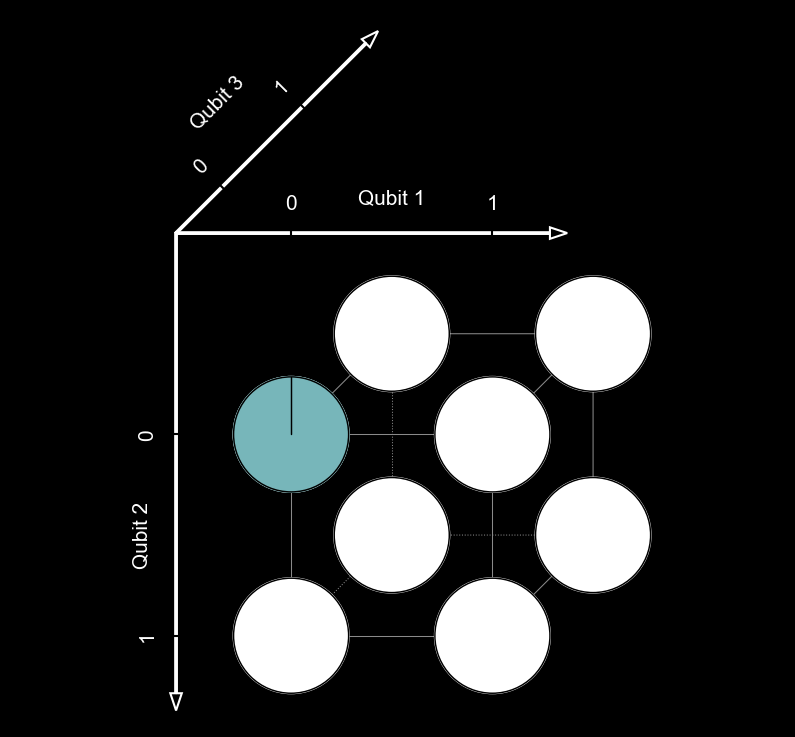

In [5]:
from qc_interactive_education_package.visualization import DimensionalCircleNotation

# 1. Instantiate the visualization for the current circuit state
vis = DimensionalCircleNotation.from_qiskit(viewer.circuit)
vis.show()

# 2. Save directly to your local Jupyter directory (PNG or SVG)
# vis.exportPNG("current_state.png", title="My Quantum State")
# vis.exportSVG("current_state.svg", title="My Quantum State")

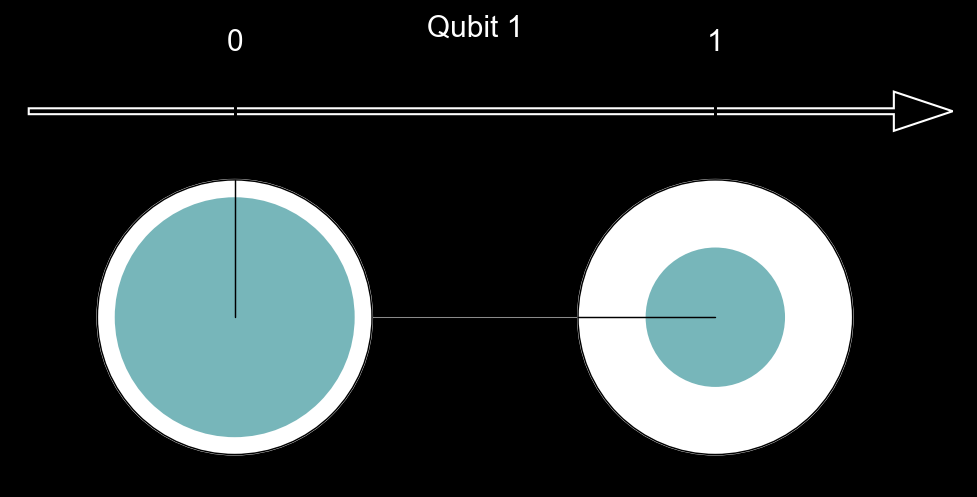

In [6]:
from qiskit.quantum_info import random_statevector, Statevector
import numpy as np

psi = Statevector([np.sqrt(3)/2,0.5j],dims=(2,)) # custom one-qubit state
# for a random two-dimensional statevector, use psi = random_statevector(2)

DimensionalCircleNotation.from_qiskit(psi).show()

In [1]:
from qc_interactive_education_package import InteractiveViewer
from qiskit import QuantumCircuit

# 1. Construct the algorithm
algo_qc = QuantumCircuit(3)
algo_qc.h(0)
algo_qc.cx(0, 1)
algo_qc.cx(1, 2)
algo_qc.x(2)

# 2. Instantiate the viewer with the algorithm preloaded into the timeline
viewer = InteractiveViewer(num_qubits=3, preloaded_circuit=algo_qc)

# 3. Render the interface
viewer.display(show_circuit=True)

In [ ]:
from qc_interactive_education_package import launch_app
from qiskit import QuantumCircuit

# 1. Construct the algorithm
algo_qc = QuantumCircuit(3)
algo_qc.h(0)
algo_qc.cx(0, 1)
algo_qc.cx(1, 2)
algo_qc.x(2)

launch_app(num_qubits=3,initial_state=[1,1,1,1,1,1,1,1],preloaded_circuit=algo_qc)

Initializing Quantum Education Suite SPA (Sandbox Mode)...
Starting local server... A browser window will open automatically once ready.


In [5]:
from qc_interactive_education_package import ChallengeViewer
from qiskit import QuantumCircuit

optimal_solution = QuantumCircuit(2)
optimal_solution.h(0)
optimal_solution.cx(0, 1)

viewer = ChallengeViewer(
    num_qubits=2,
    initial_state=[1, 0, 0, 0],
    target_state=[0.707, 0, 0, 0.707],
    preloaded_circuit=optimal_solution
)

viewer.display(show_circuit=True)

In [4]:
from qc_interactive_education_package import ChallengeViewer
from qiskit import QuantumCircuit
import numpy as np

# ==========================================
# TEST 1: Absolute Minimalist Instantiation
# ==========================================
print("--- Launching Test 1: Ground State Deduction ---")

qc_minimal = QuantumCircuit(2)
qc_minimal.h(0)
qc_minimal.cx(0, 1)

# Notice the strict omission of initial_state and target_state.
# The viewer must logically deduce both the |00> start and the Bell state end.
viewer_minimal = ChallengeViewer(
    num_qubits=2,
    preloaded_circuit=qc_minimal,
    is_assessment=True
)

# Displaying the viewer. You should see "Current State" at |00>
# and "Target State" fully resolved to the Bell state.
viewer_minimal.display(show_circuit=True)

--- Launching Test 1: Ground State Deduction ---


In [4]:

# ==========================================
# TEST 2: Embedded Initialization Extraction
# ==========================================
print("\n--- Launching Test 2: Circuit-Driven Initialization ---")

qc_embedded = QuantumCircuit(2)

# Define a custom starting state: |+0>
inv_sq2 = 1.0 / np.sqrt(2)
custom_start = [inv_sq2, inv_sq2, 0.0, 0.0]

# Inject the initialization directly into the Qiskit timeline
qc_embedded.initialize(custom_start, qc_embedded.qubits)

# Apply a CNOT. Since the control is in |+>, this will generate a Bell state.
qc_embedded.cx(0, 1)

# Again, strictly omitting initial_state and target_state arguments.
viewer_embedded = ChallengeViewer(
    num_qubits=2,
    preloaded_circuit=qc_embedded,
    is_assessment=False
)

# Displaying the viewer. The "Current State" should immediately render as |+0>
# (proving the extraction worked) and the Undo history should NOT contain "Initialize".
viewer_embedded.display(show_circuit=True)


--- Launching Test 2: Circuit-Driven Initialization ---


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

# Import the newly updated launch function
# (Assuming your launcher functions are saved in 'launch_viewer.py')
from qc_interactive_education_package import launch_app

def run_bell_state_test():
    """
    Validates the Inter-Process Communication (IPC) by passing a
    precompiled Qiskit circuit through the OS layer to the Voilà server.
    """
    print("Constructing target algorithm...")

    # 1. Define the mathematical target state: a maximally entangled Bell state.
    # We use numpy to ensure precise floating-point arithmetic for the amplitudes.
    amp = 1.0 / np.sqrt(2)


    # 2. Construct the optimal algorithmic solution (the Preloaded Circuit).
    optimal_qc = QuantumCircuit(2)
    optimal_qc.h(0)        # Create superposition on the first qubit
    optimal_qc.cx(0, 1)    # Entangle the second qubit via CNOT
    bell_target_state = Statevector.from_instruction(optimal_qc).data

    print("Algorithm constructed successfully. Dispatching to Voilà IPC...")

    # 3. Launch the challenge environment.
    # The 'optimal_qc' will be serialized to QASM, passed through os.environ,
    # and reconstructed inside 'challenge.ipynb' to populate the Redo stack.
    launch_app(
        mode="challenge",
        num_qubits=2,
        initial_state=[1.0, 0.0, 0.0, 0.0],  # Standard |00> initialization
        target_state=bell_target_state,
        show_circuit=True,                   # Required to see the ghost overlay
        preloaded_circuit=optimal_qc,        # shows the solution
    )

run_bell_state_test()

Constructing target algorithm...
Algorithm constructed successfully. Dispatching to Voilà IPC...
Initializing Quantum Education Suite SPA (Challenge Mode)...
Starting local server... A browser window will open automatically once ready.


In [ ]:
from qc_interactive_education_package.quantum_library import QuantumCurriculum
from qc_interactive_education_package import launch_app

# 1. Retrieve the pre-compiled algorithms from the curriculum
algorithms = QuantumCurriculum.get_algorithms()

# 2. Extract the exact 5-qubit Grover matrix
shors_algo = algorithms["Shor's Algorithm: Factor 15 (8Q)"]

# 3. Instantiate the viewer directly into the active DOM
# The viewer will automatically deduce the initial and target states
# based on the architectural updates we implemented.
launch_app(
    mode='algorithm',
    num_qubits=8,
    preloaded_circuit=shors_algo,
    show_circuit=True,
    show_annotations=True,
    show_final_state = False
)

Initializing Quantum Education Suite SPA (Algorithm Mode)...
Starting local server... A browser window will open automatically once ready.


In [ ]:
from qc_interactive_education_package.quantum_library import QuantumCurriculum
from qc_interactive_education_package import launch_app

# 1. Retrieve the pre-compiled algorithms from the curriculum
algorithms = QuantumCurriculum.get_algorithms()

# 2. Extract the exact 5-qubit Grover matrix
dj_algo = algorithms["Deutsch-Jozsa Algorithm: Balanced (3Q Input)"]

# 3. Instantiate the viewer directly into the active DOM
# The viewer will automatically deduce the initial and target states
# based on the architectural updates we implemented.
launch_app(
    mode='algorithm',
    num_qubits=4,
    preloaded_circuit=dj_algo,
    show_circuit=True,
    show_annotations=True,
    show_final_state = False
)

Initializing Quantum Education Suite SPA (Algorithm Mode)...
Starting local server... A browser window will open automatically once ready.
